# 📈 Modélisation – Régression Linéaire
---

Après avoir nettoyé les données et analysé les relations entre les investissements publicitaires et les ventes, nous passons à la phase de **modélisation prédictive**.

L’objectif de cette étape est de **quantifier l’impact de chaque canal publicitaire sur les ventes** et de **prédire les ventes** à partir des budgets investis en publicité.  
Pour cela, nous utilisons un modèle de **régression linéaire**, adapté à l’étude de relations linéaires entre variables quantitatives.

Dans cette section, nous allons :
- Séparer les données en jeux d’entraînement et de test
- Construire un modèle de régression linéaire
- Évaluer la performance du modèle
- Interpréter les coefficients pour en tirer des enseignements métier

Cette approche permettra de transformer les analyses exploratoires en **résultats concrets et exploitables**.


## 📦 Importation des bibliothèques

In [4]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import sklearn as sk

## 📂 Chargement du dataset nettoyé


In [5]:
df=pd.read_csv('../data/processed/advertising_cleaned.csv')

## 🧩 Préparation des données pour la modélisation

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Avant d’entraîner un modèle de régression linéaire, il est nécessaire de préparer les données en identifiant clairement les variables explicatives et la variable cible.  
Les investissements publicitaires (TV, Radio, Newspaper) sont utilisés comme variables explicatives, tandis que les ventes représentent la variable à prédire.

Le jeu de données est ensuite divisé en un ensemble d’entraînement et un ensemble de test.  
Cette séparation permet d’entraîner le modèle sur une partie des données et d’évaluer sa capacité à généraliser sur des données qu’il n’a jamais vues.

### 📝 En résumé
Cette étape consiste à définir **ce que le modèle doit apprendre** et **comment évaluer ses performances**, constituant ainsi une base essentielle pour construire un modèle prédictif fiable.


## 🤖 Entraînement du modèle de régression linéaire

In [7]:
# Create a Linear Regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(X_train, y_train)


LinearRegression()

## 📉 Visualisation des prédictions du modèle (jeu d’entraînement)


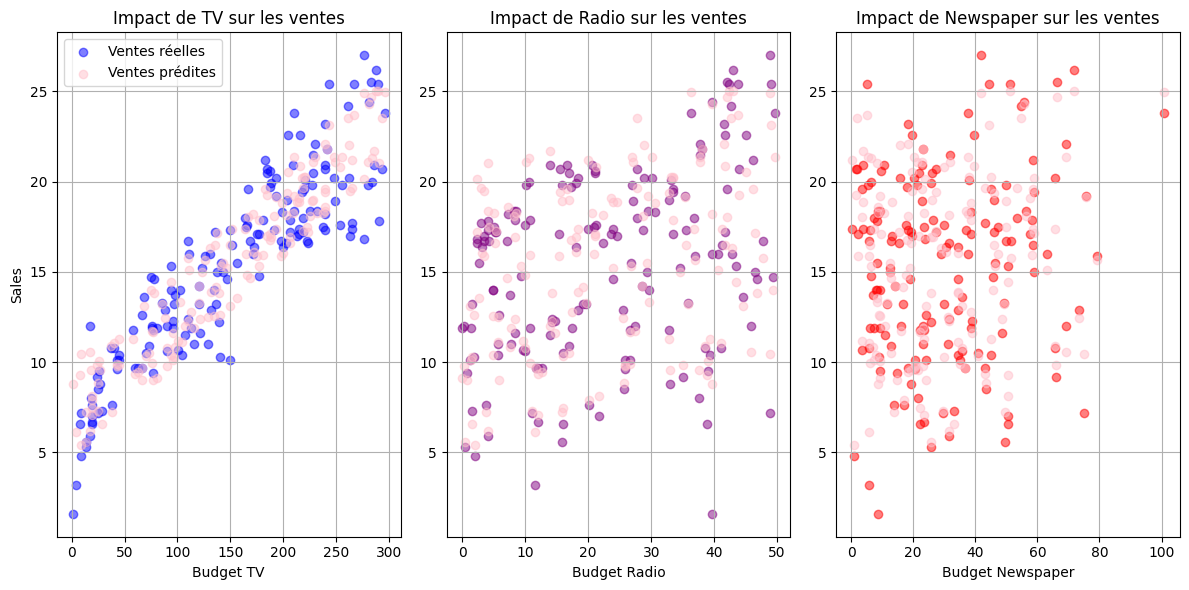

In [8]:
y_train_pred = model.predict(X_train)

fig, axs = plt.subplots(1, 3, figsize=(12, 6))

features = ['TV', 'Radio', 'Newspaper']
colors = ['blue', 'purple', 'red']

for i, feature in enumerate(features):
    axs[i].scatter(X_train[feature], y_train, 
                   color=colors[i], alpha=0.5, label='Ventes réelles')
    axs[i].scatter(X_train[feature], y_train_pred, 
                   color='pink', alpha=0.5, label='Ventes prédites')

    axs[i].set_title(f'Impact de {feature} sur les ventes')
    axs[i].set_xlabel(f'Budget {feature}')
    axs[i].grid(True)

axs[0].set_ylabel('Sales')
axs[0].legend()

plt.tight_layout()
plt.show()


### 📊 Interprétation des visualisations du modèle

Ces graphiques représentent la relation entre chaque canal publicitaire et les ventes, en comparant les **valeurs réelles** aux **valeurs prédites** par le modèle de régression linéaire.  
Bien que le modèle soit multivarié, chaque graphique correspond à une projection 2D permettant de mieux comprendre l’impact individuel de chaque variable explicative.



#### 📺 Impact de la TV sur les ventes
La relation entre le budget TV et les ventes est fortement linéaire.  
On observe que les ventes augmentent de manière significative lorsque l’investissement TV augmente, et les prédictions du modèle suivent de très près les valeurs réelles.

➡️ **La TV est le levier publicitaire le plus influent sur les ventes.**



#### 📻 Impact de la Radio sur les ventes
La radio présente une relation positive avec les ventes, mais avec une dispersion plus importante.  
L’impact existe, mais il est moins marqué que celui de la TV.

➡️ **La radio joue un rôle complémentaire dans la génération des ventes.**



#### 📰 Impact du Newspaper sur les ventes
La relation entre le budget Newspaper et les ventes est faible.  
Les points sont très dispersés et aucune tendance claire ne se dégage, ce qui indique un impact limité sur les ventes.

➡️ **La presse écrite semble avoir peu d’influence directe sur les ventes.**



### 🧠 Conclusion globale
Les visualisations confirment les résultats de l’analyse exploratoire et de la corrélation :
- La **TV** est le principal moteur des ventes
- La **Radio** a un impact modéré
- Le **Newspaper** contribue faiblement à la prédiction des ventes

Ces résultats justifient l’utilisation d’un modèle de régression linéaire pour quantifier l’impact des investissements publicitaires.


## 📊 Comparaison des ventes réelles et prédites (jeu de test)


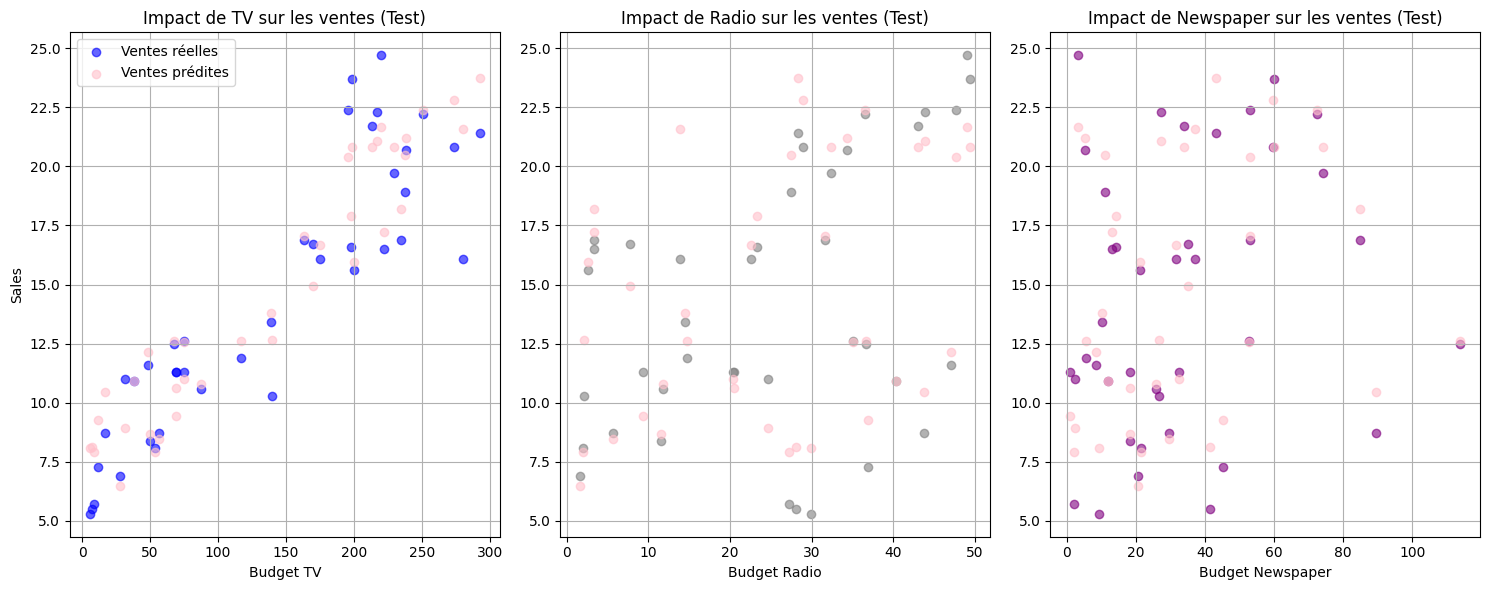

In [11]:
# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# Prédictions sur les données de test
y_test_pred = model.predict(X_test)

# Noms des variables explicatives et couleurs
features = ['TV', 'Radio', 'Newspaper']
colors = ['blue', 'grey', 'purple']

for i, feature in enumerate(features):
    # Ventes réelles
    axs[i].scatter(
        X_test[feature],
        y_test,
        color=colors[i],
        alpha=0.6,
        label='Ventes réelles'
    )

    # Ventes prédites
    axs[i].scatter(
        X_test[feature],
        y_test_pred,
        color='pink',
        alpha=0.6,
        label='Ventes prédites'
    )

    axs[i].set_title(f'Impact de {feature} sur les ventes (Test)')
    axs[i].set_xlabel(f'Budget {feature}')
    axs[i].grid(True)

# Éléments communs
axs[0].set_ylabel('Sales')
axs[0].legend()

plt.tight_layout()
plt.show()


### 📊 Analyse des prédictions sur le jeu de test

Ces graphiques comparent les **ventes réelles** et les **ventes prédites** par le modèle sur le jeu de test, c’est-à-dire sur des données que le modèle n’a jamais vues lors de l’entraînement.  
Ils permettent d’évaluer visuellement la capacité du modèle à **généraliser**.



#### 📺 Impact de la TV sur les ventes (Test)
La relation entre le budget TV et les ventes reste clairement linéaire sur le jeu de test.  
Les ventes prédites suivent de près les ventes réelles, ce qui indique que le modèle généralise très bien cette relation.

➡️ **La TV demeure le principal levier explicatif des ventes.**



#### 📻 Impact de la Radio sur les ventes (Test)
La radio conserve une tendance positive, bien que plus dispersée.  
Les prédictions sont globalement cohérentes, mais présentent davantage de variabilité.

➡️ **La radio a un impact réel mais secondaire sur les ventes.**



#### 📰 Impact du Newspaper sur les ventes (Test)
La dispersion reste élevée et aucune relation claire ne se dégage entre le budget Newspaper et les ventes.  
Les prédictions sont moins précises, confirmant le faible pouvoir explicatif de cette variable.

➡️ **La presse écrite contribue peu à la prédiction des ventes.**



### 🧠 Conclusion
Les résultats observés sur le jeu de test confirment les analyses précédentes :
- Le modèle généralise correctement
- Les relations identifiées en EDA sont stables
- La TV est le facteur le plus influent, suivie de la radio
- Le Newspaper a un impact limité


## 📏 Évaluation des performances du modèle


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_test_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("📊 Performance du modèle sur le jeu de test")
print("=" * 45)
print(f"🔹 Mean Squared Error (MSE)  : {mse:.2f}")
print(f"🔹 Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f"🔹 Coefficient de détermination (R²) : {r2:.2f}")

📊 Performance du modèle sur le jeu de test
🔹 Mean Squared Error (MSE)  : 2.91
🔹 Root Mean Squared Error (RMSE) : 1.71
🔹 Coefficient de détermination (R²) : 0.91


### 📊 Interprétation des métriques

- **MSE (Mean Squared Error)** mesure l’erreur moyenne au carré entre les ventes réelles et les ventes prédites.  
  Une valeur faible indique que les prédictions sont proches des observations réelles.

- **RMSE (Root Mean Squared Error)** est l’erreur moyenne exprimée dans la même unité que la variable cible (ventes).  
  Ici, le modèle se trompe en moyenne d’environ **1,7 unité de ventes**, ce qui reste raisonnable au regard de l’échelle des ventes.

- **R² (coefficient de détermination)** indique la proportion de la variance des ventes expliquée par le modèle.  
  Un R² de **0,91** signifie que **91 % des variations des ventes** sont expliquées par les investissements publicitaires.

### ✅ Conclusion
Le modèle de régression linéaire présente de **très bonnes performances prédictives** et capture efficacement la relation entre les budgets publicitaires et les ventes.


## 💾 Sauvegarde du modèle entraîné

In [13]:
import os
import joblib

# Créer le dossier models
os.makedirs("models", exist_ok=True)

# Sauvegarde du modèle
joblib.dump(model, "models/linear_regression_sales.pkl")

print("✅ Modèle sauvegardé avec succès dans le dossier 'models'")


✅ Modèle sauvegardé avec succès dans le dossier 'models'


## 🚀 Utilisation du modèle pour une prédiction

In [2]:
import numpy as np
import joblib

# 1. Charger le modèle entraîné
loaded_model = joblib.load("../models/linear_regression_sales.pkl")

# 2. Définir un nouveau scénario d’investissement
new_budget = np.array([[950, 400, 300]])  # TV, Radio, Newspaper

# 3. Prédiction des ventes
sales_pred = loaded_model.predict(new_budget)

print(
    "📊 Prédiction des ventes\n"
    "-------------------------\n"
    "💡 Scénario d’investissement :\n"
    "   • TV : 950 €\n"
    "   • Radio : 400 €\n"
    "   • Newspaper : 300 €\n\n"
    f"📈 Ventes estimées : {sales_pred[0]:,.2f} unités\n"
    "-------------------------\n"
    "👉 Cette estimation est basée sur le modèle de régression linéaire entraîné."
)

📊 Prédiction des ventes
-------------------------
💡 Scénario d’investissement :
   • TV : 950 €
   • Radio : 400 €
   • Newspaper : 300 €

📈 Ventes estimées : 98.18 unités
-------------------------
👉 Cette estimation est basée sur le modèle de régression linéaire entraîné.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
